### **Instalación**

In [12]:
!pip install pandas numpy matplotlib -q

### **Imports**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Librerias importadas.")


Librerias importadas.


### **Cargar dataset**

In [15]:
from google.colab import files
uploaded = files.upload()  # selecciona sales_data_sample.csv

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Saving sales_data_sample.csv to sales_data_sample (1).csv
Dataset cargado: 2823 filas, 25 columnas


### **Exploración general**

In [16]:
print("=== NULOS ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== TIPOS ===")
print(df.dtypes)
df.head(3)

=== NULOS ===
ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64

=== TIPOS ===
ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY            object
CONTACTLASTNAME      object
CONTACTFIRSTNAME     object
DEALSIZE             object
dtype: object


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium


### **Eliminar columnas innecesarias**

In [18]:
df = df.drop(columns=["ADDRESSLINE2", "PHONE"], errors="ignore")
print("Columnas eliminadas. Quedan:", df.shape[1])

Columnas eliminadas. Quedan: 23
Columnas eliminadas. Quedan: 23


### **Tratar valores nulos restantes**

In [19]:
df["STATE"]      = df["STATE"].fillna("N/A")
df["POSTALCODE"] = df["POSTALCODE"].fillna("N/A")
df["TERRITORY"]  = df["TERRITORY"].fillna("N/A")
print("Nulos restantes:", df.isnull().sum().sum())

Nulos restantes: 0


### **Fechas y variables temporales**

In [20]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])
df["YEAR"]      = df["ORDERDATE"].dt.year
df["MONTH"]     = df["ORDERDATE"].dt.month
df["QUARTER"]   = df["ORDERDATE"].dt.quarter
df["DAY"]       = df["ORDERDATE"].dt.day

df = df.drop(columns=["QTR_ID", "MONTH_ID", "YEAR_ID"], errors="ignore")
print("Variables temporales creadas.")
print(df[["ORDERDATE","YEAR","MONTH","QUARTER"]].head())

Variables temporales creadas.
   ORDERDATE  YEAR  MONTH  QUARTER
0 2003-02-24  2003      2        1
1 2003-05-07  2003      5        2
2 2003-07-01  2003      7        3
3 2003-08-25  2003      8        3
4 2003-10-10  2003     10        4


### **Limpieza de texto**

In [21]:
cols_texto = ["CUSTOMERNAME","COUNTRY","PRODUCTLINE",
              "STATUS","DEALSIZE","TERRITORY","CITY"]
for col in cols_texto:
    df[col] = df[col].str.strip().str.upper()
print("Texto normalizado.")

Texto normalizado.


### **Codificación categórica**

In [22]:
df["DEALSIZE_CODE"] = df["DEALSIZE"].map(
    {"SMALL": 1, "MEDIUM": 2, "LARGE": 3}
)
df["STATUS_CODE"] = df["STATUS"].map({
    "SHIPPED": 1, "RESOLVED": 2, "CANCELLED": 3,
    "ON HOLD": 4, "DISPUTED": 5, "IN PROCESS": 6
})
print(df[["DEALSIZE","DEALSIZE_CODE","STATUS","STATUS_CODE"]].head())

  DEALSIZE  DEALSIZE_CODE   STATUS  STATUS_CODE
0    SMALL              1  SHIPPED            1
1    SMALL              1  SHIPPED            1
2   MEDIUM              2  SHIPPED            1
3   MEDIUM              2  SHIPPED            1
4   MEDIUM              2  SHIPPED            1


### **Gráfico**

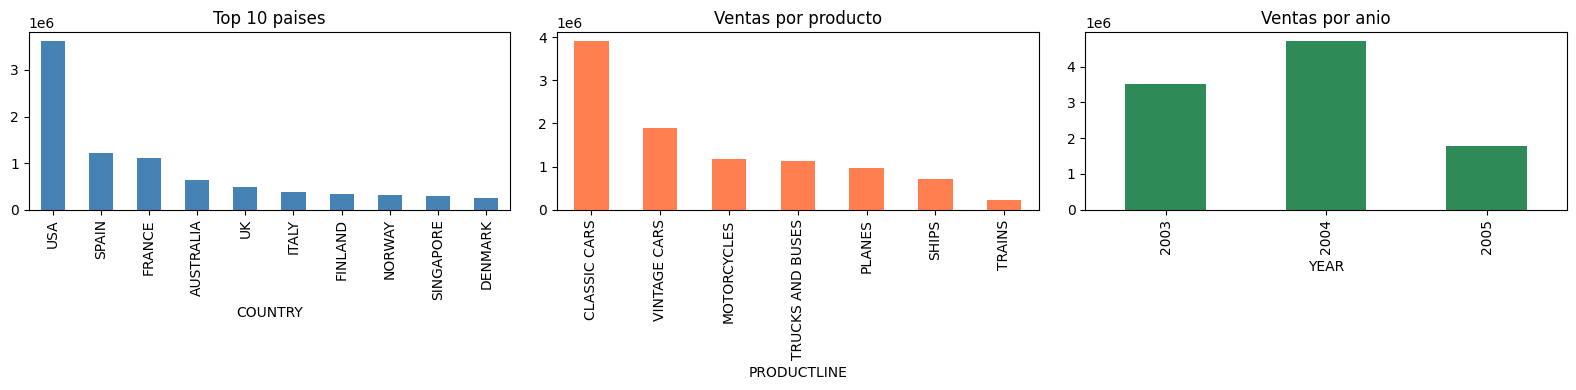

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False).head(10)\
  .plot(kind="bar", ax=axes[0], color="steelblue", title="Top 10 paises")

df.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)\
  .plot(kind="bar", ax=axes[1], color="coral", title="Ventas por producto")

df.groupby("YEAR")["SALES"].sum()\
  .plot(kind="bar", ax=axes[2], color="seagreen", title="Ventas por anio")

plt.tight_layout()
plt.show()

### **Exportar dataset normalizado**

In [24]:
df.to_csv("ventas_normalizado.csv", index=False)
print(f"ventas_normalizado.csv guardado: {df.shape[0]} filas, {df.shape[1]} columnas")

from google.colab import files
files.download("ventas_normalizado.csv")

ventas_normalizado.csv guardado: 2823 filas, 26 columnas


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>